# Discrete distributions

In [10]:
from phasic import Graph, with_ipv
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from vscodenb import set_vscode_theme
sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)


Consider this simple graph representing an exponential distribution. If you must, you can make it the coalescence time of two lineages in very small population:

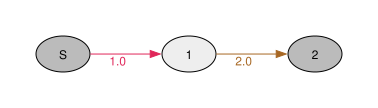

In [11]:
def exponential(state):
    transitions = []               # List for transitions from state
    if state[0] < 2:               # Control transitions allowed
        child = state.copy()       # Make a copy to modify
        child[0] += 1              # Make the child state
        trans = [child, 2.0]       # Pair the child with a transition rate
        transitions.append(trans)  # Append transition 
    return transitions

graph = Graph(exponential, ipv=[1])
graph.plot()

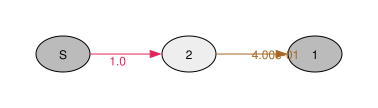

In [12]:
def exponential(rate):
    graph = Graph(1)
    vertex = graph.find_or_create_vertex([2])
    graph.starting_vertex().add_edge(vertex, 1)
    abs_vertex = graph.find_or_create_vertex([1])
    vertex.add_edge(abs_vertex, rate)
    return graph

graph = exponential(0.4)
graph.plot()

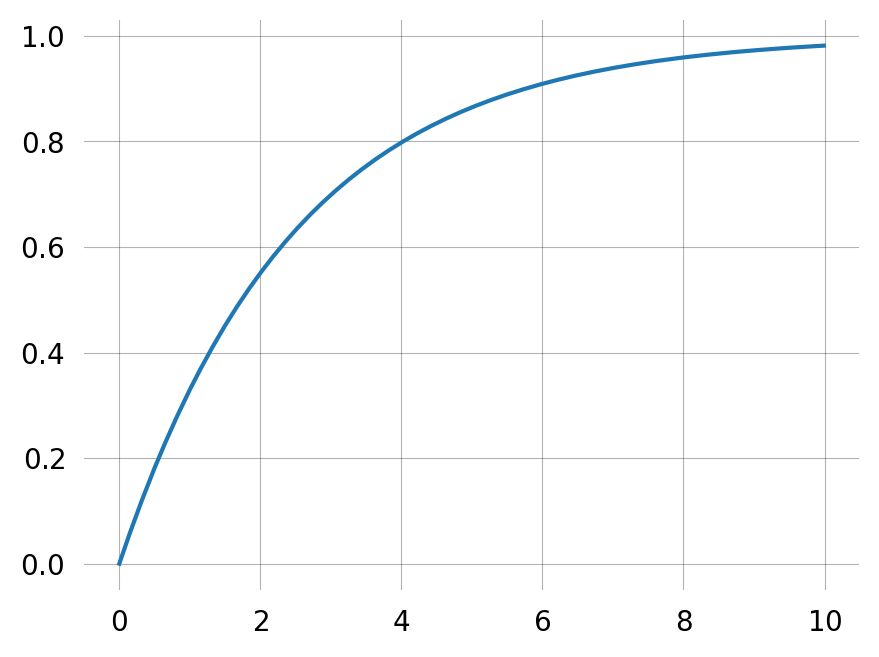

In [13]:
rate = 0.4
x = np.arange(0, 10, 0.01)
graph = exponential(rate)
plt.plot(x, graph.cdf(x))
plt.show()

Discrete phase-type distributions represent the the number of jumps in a Markov Chain before absorption. We can discretize our graph it to get a geometric distribution:

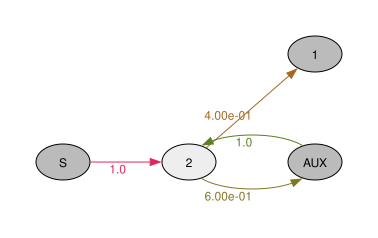

In [14]:
#| label: fig-discrete-aux-vertex
graph = exponential(0.4)
graph = graph.discretize(1-rate)
graph.plot()

The `discretize` method returns a new graph, by connecting each non-absorbing vertex in the graph to an auxiliary vertex with a specified rate. Each AUX vertex connects to its parent with rate 1. Once AUX vertices are added, the graph is normalized so the sum of edge weights sum to 1 for each vertex. `discretize` returns a new graph with a `.rewards` attribute containing the indices of the added AUX vertices.



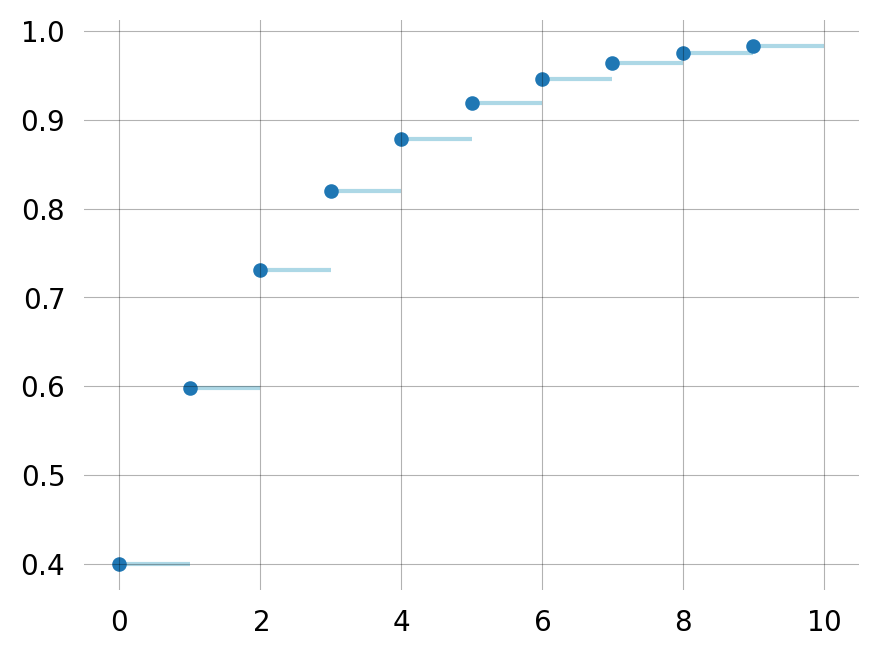

In [15]:
#| label: fig-geometric
#| fig-cap: "Continuous (exponential) distribution "
x = np.arange(10)
cdf = graph.reward_transform(graph.rewards).cdf(x)
plt.hlines(y=cdf, xmin=x, xmax=x+1, zorder=1, color='lightblue')
plt.scatter(x, cdf, s=18)
plt.show()

You can treat the discrete graph by passing `discrete=False` (omit the argument), in which case the returned distribution is over continuous time, rather than discrete jumps:

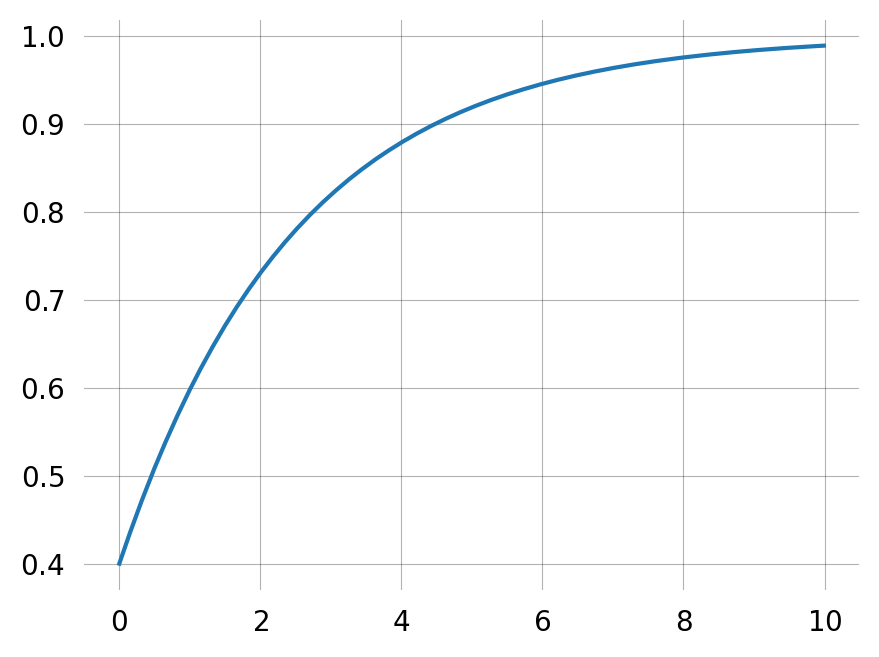

In [16]:
#| label: fig-geometric-as-exponential
#| fig-cap: "Treating geometric as continuous (exponential) distribution"


rate = 0.4
graph = exponential(rate)
graph = graph.discretize(1-rate)
x = np.arange(0, 10, 0.01)
cdf = graph.reward_transform(graph.rewards).cdf(x)
plt.plot(x, cdf)
plt.show()

::: { .callout-tip }

## Continuous / Discrete method behavior

You can use many of the graph methods on both continuous and discrete graphs. 

The methods `moments`, `expectation`, `variance`, `covariance`, `pdf`, `cdf`, `distribution_context`, `sample`, `state_probability`, and `accumulated_occupancy` will treat the graph as continuous unless the `discrete=True` keyword argument is passed. In this case moments and probabilities are computed across discrete jumps rather than across continuous time.

It is sometimes useful to interpret a discrete graph as a continuous distribution. However, passing `discrete=True` to a method called on a continuous will raise a `ValueError`, since continuous graph has not discrete interpretation.

Methods without the `discrete` keyword argument, either apply to both kinds of graphs (`expected_waiting_time`), or automatically redirect to functions handling each kind (`normalize`, `reward_transform`).

:::

::: { .callout-tip }

If you make the distribution discrete using `discretize`, it changes the `is_discrete` graph attribute to `True`. 

**NB:** if you make a discrete graph manually yourself, you need to either set `graph.is_discrete = True`, or call the appropriate "*_discrete" methods directly.

:::


To model discrete mutations with rate 0.1 along branches of the coalescent tree. We could of course just make a new state-space creation function, but we can also manipulate an existing continuous one.


E.g. if you want to get the distribution of accumulated mutations over time rather than jumps. 


Let's model discrete mutations with rate 0.1 along branches of the coalescent tree. We could of course just make a new state-space creation function, but we can also manipulate an existing continuous one.

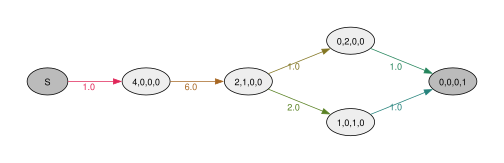

In [8]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

mutation_graph = Graph(coalescent)
mutation_graph.plot()

This process is automated by the `discretize` method, which accepts either a single rate of discrete events for all state (E.g. `graph.discretize(0.7)`), or a callable mapping each state vector to a rate. The following example produces the mutation graph above:

In [17]:
from typing import Optional

mutation_graph = Graph(coalescent)

def mutation(state:np.ndarray, mutation_rate:float):
    nr_lineages = sum(state)
    return nr_lineages * mutation_rate

mutation_rate = 0.1
mutation_graph = mutation_graph.discretize(rate=mutation_rate)
rewards = mutation_graph.rewards

The auxiliary nodes added have dummy states with all zeros and are labelled as "AUX" vertices when the graph is plotted:

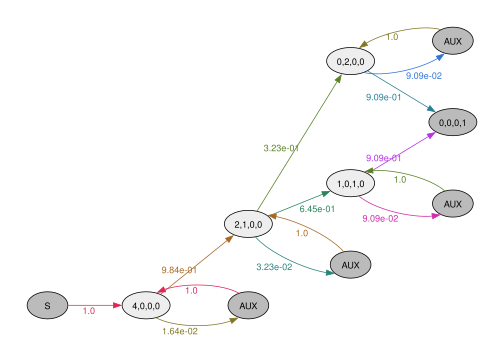

In [18]:
#| label: fig-discretize
mutation_graph.plot()

If you want, you can assign nodes to subgraphs either by index or by state, by passing a callable as the `by_index` or `by_state` argument. For example, we can group the auxiliary nodes we added above into a separate subgraph:

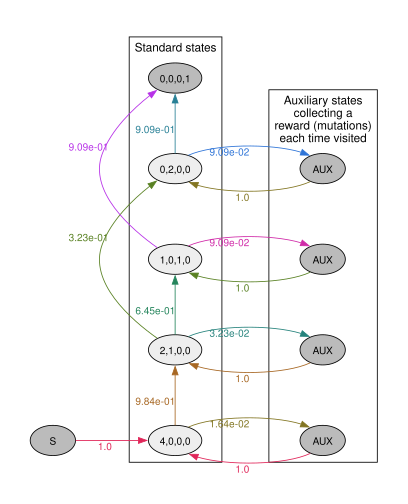

In [19]:
#| label: fig-mutations-aux-subgraph
#| fig-cap: "Grouping states into auxiliary and standard states."


def fun(index):
    if rewards[index]:
        return "Auxiliary states\ncollecting a\nreward (mutations)\neach time visited"
    else:
        return "Standard states"

mutation_graph.plot(by_index=fun)

To find compute the expected number of mutations, we apply rewards such that the mutation vertex get a reward of 1 and all other states get reward of 0. Since this is already encoded in the `mutation_vertices` array we made above, we can convert it to integers and pass it as rewards:


In [20]:
mutation_graph.expectation(rewards)

0.15

We can verify that the expected number of mutations correspond to the total branch length scaled with the mutation rate:

In [21]:
graph = Graph(coalescent)
tot_brlen = graph.expectation(graph.states().T.sum(axis=0))
tot_brlen * mutation_rate

0.3666666666666667

In [22]:
#| echo: false
if 'pytest' in sys.modules: assert pytest.approx(tot_brlen * mutation_rate) == tot_brlen * mutation_rate

Or compare it to emprical mean of samples from the models

In [23]:
samples = mutation_graph.sample(10000, rewards=rewards)
samples.mean().item()

0.1511

In [24]:
rewards = graph.states().T
rewards = rewards[:-1].sum(axis=0)
samples = graph.sample(10000, rewards=rewards)
samples.mean().item() * mutation_rate

0.36551843863487166

If we reward transform the graph, we can find the distribution function for the the total number of mutations:

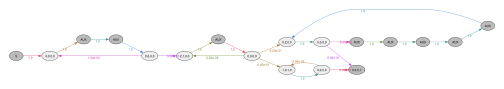

In [25]:
#| label: fig-discrete-rev-trans
rev_trans_mutation_graph  = mutation_graph.reward_transform_discrete(rewards)
rev_trans_mutation_graph.plot()

Notice that with this reward transformation the graph is no longer sparse, as all paths through the graph are represented.


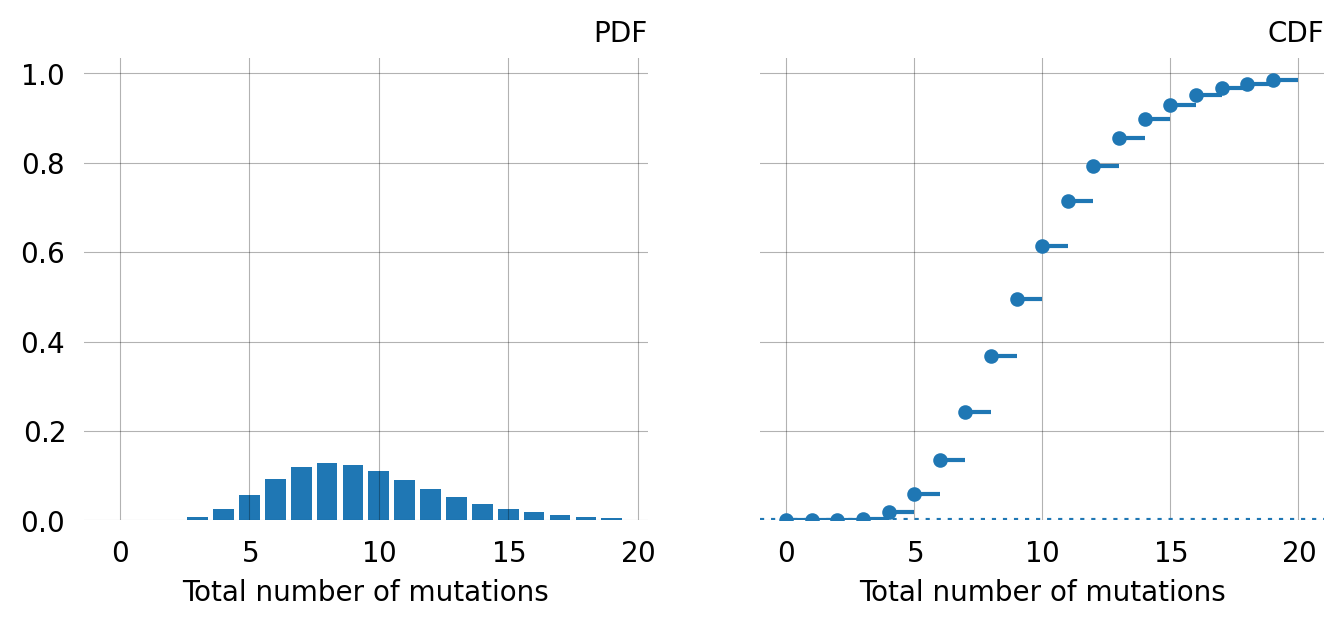

In [26]:
#| label: fig-discrete-pmf-cdf
x = np.arange(20)
pmf = rev_trans_mutation_graph.pdf(x)
cdf = rev_trans_mutation_graph.cdf(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
ax1.bar(x, pmf)
ax1.set_title("PDF")
ax1.set_xlabel('Total number of mutations')
left, right = x, np.arange(1, x.size+1, 1)
ax2.hlines(y=cdf, xmin=left, xmax=right, zorder=1)
ax2.scatter(left, cdf, s=18, zorder=2)
ax2.set_title("CDF")
ax2.set_xlabel('Total number of mutations')
ax2.axhline(y=mutation_graph.defect(), linestyle='dotted') ;

# Multivariate phase-type distributions (marginal)

We can compute marginal expectations using rewards. Instead of a univariate reward, we can have the distribution earn a *vector* of rewards for every time unit spent at *each* vertex. We can use the columns in our state matrix as reward vectors. Singleton rewards are:

In [27]:
graph = Graph(coalescent)
mutation_graph = graph.discretize(rate=1.0)

ValueError: rate must be in (0, 1), got 1.0

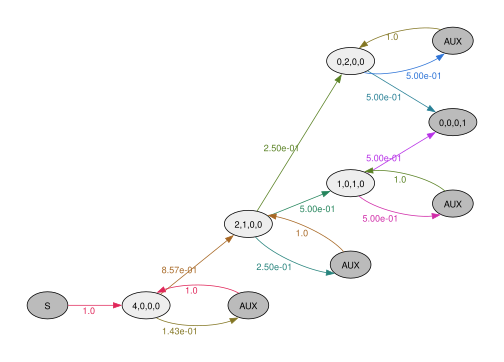

In [46]:
graph = Graph(coalescent)
mutation_graph = graph.discretize(rate=0.999999999)
mutation_graph.plot()


In [47]:
mutation_graph.rewards

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

**Would be nice to be able to just supply rewards as if the graph was cont**

In [79]:
orig_graph_rev_idx = np.arange(1, graph.vertices_length()-1)
rewards = np.concatenate([graph.states().T, graph.states().T[:,orig_graph_rev_idx]], axis=1)
rewards = rewards[:-1]
rewards = rewards * mutation_graph.rewards
rewards

array([[0, 0, 0, 0, 0, 0, 4, 2, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 2, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
rewards = mutation_graph.states().T

mutation_graph
#rewards = rewards[:-1]
rewards = np.concatenate([rewards[:, np.array([5, 6, 7, 8])], rewards[:, np.array([1, 2, 3, 4])]], axis=1)
rewards

array([[0, 4, 2, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 2, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]], dtype=int32)

In [81]:
[mutation_graph.expectation(r) for r in rewards]

[1.999999998, 0.999999999, 0.666666666]

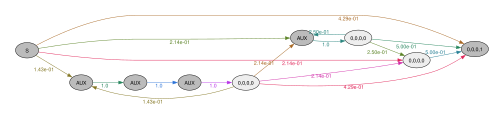

In [121]:
singleton_graph = mutation_graph.reward_transform(rewards[0])
singleton_graph.plot(nodesep=0.3)

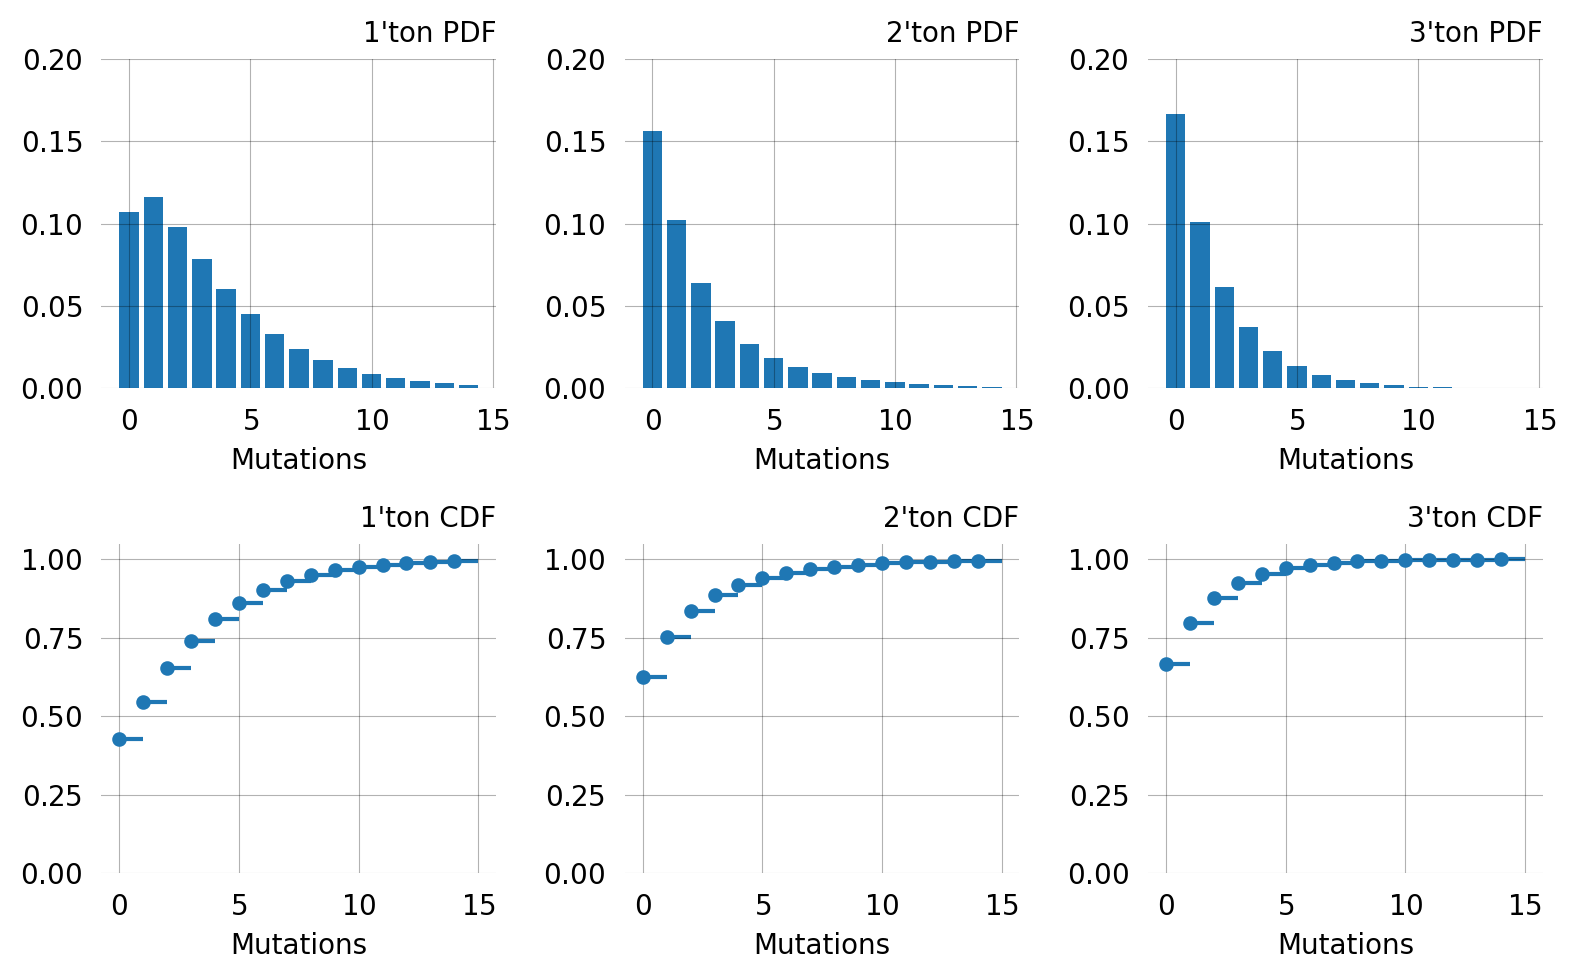

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5))
x = np.arange(0, 15)
for i, r in enumerate(rewards):
    
    # reward transform and compute pdf (pmf) and cdf:
    revt_graph = mutation_graph.reward_transform(r)
    pmf = revt_graph.pdf(x)
    cdf = revt_graph.cdf(x)

    # plot it
    axes[0, i].set_title(f"{i+1}'ton PDF")
    axes[0, i].bar(x, pmf)
    axes[0, i].set_xlabel('Mutations')
    axes[0, i].set_ylim(0, 0.2)
    left, right = x, np.arange(1, x.size+1, 1)
    axes[1, i].hlines(y=cdf, xmin=left, xmax=right, zorder=1)
    axes[1, i].scatter(left, cdf, s=18, zorder=2)
    axes[1, i].set_title(f"{i+1}'ton CDF")
    axes[1, i].set_xlabel('Mutations')
    axes[1, i].set_ylim(0, 1.05)
plt.tight_layout()